# 호텔검색 10,000명 합성 A/B: NSM·KPI·가설 분석

이 노트북은 10,000명 합성 SQLite를 읽기 전용으로 분석한다. 실제 사용자 무작위 실험이 아니며, 실험군에 `Z→P +0.06`이 생성 규칙으로 들어간 시뮬레이션이다.

**임시 지표 계약**

- NSM 후보: 즉시 회복률 = 0건 후 다음 검색이 있는 전이 중 다음 결과가 1건 이상인 전이
- KPI: 검색 0건률, 후속검색률, 첫 Z 즉시 회복률, 최종 회복률, Card H-SEARCH
- 주 분석: 전체 배정군 control vs treatment
- 불확실성: `pair_id` 단위 2,000회 bootstrap
- 인과 해석: 금지. 합성 모형 안의 설정 작동 여부만 판단


In [2]:
from pathlib import Path
import json, sqlite3, hashlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

DB = Path(r'''C:\Users\ENCO\Downloads\호텔검색_1만명증강_탐색용AB10000_260907_1544_01_ERD보존_정수키_16K.sqlite''')
OUT = Path.cwd()
FIG = OUT / 'figures'
FIG.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', font='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
print('DB:', DB)
print('size MiB:', DB.stat().st_size / 1024**2)


DB: C:\Users\ENCO\Downloads\호텔검색_1만명증강_탐색용AB10000_260907_1544_01_ERD보존_정수키_16K.sqlite
size MiB: 375.546875


## 1. 데이터 목록과 품질 점검

원시 grain은 사용자, 세션, 검색, 검색필터, 검색결과, 이벤트, 검색전환이다. 모든 연결은 선언된 PK·FK를 사용한다. 분석 전에 행 수, FK, A/B 균형과 중복을 확인한다.


In [3]:
con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name", con)
counts = {t: pd.read_sql_query(f'SELECT COUNT(*) n FROM "{t}"', con).iloc[0,0] for t in tables['name']}
quality = {
    'integrity_check': con.execute('PRAGMA integrity_check').fetchone()[0],
    'foreign_key_issues': len(con.execute('PRAGMA foreign_key_check').fetchall()),
    'table_counts': counts,
    'pair_balance_issues': con.execute("""SELECT COUNT(*) FROM (
      SELECT pair_id, SUM(sample_set_type='control') c, SUM(sample_set_type='treatment') t
      FROM UserSynthetic GROUP BY pair_id HAVING c<>1 OR t<>1)""").fetchone()[0],
    'duplicate_search_id': con.execute('SELECT COUNT(*)-COUNT(DISTINCT search_id) FROM Search').fetchone()[0],
    'duplicate_event_id': con.execute('SELECT COUNT(*)-COUNT(DISTINCT event_id) FROM ActionEvent').fetchone()[0],
    'duplicate_result_id': con.execute('SELECT COUNT(*)-COUNT(DISTINCT search_result_id) FROM SearchResult').fetchone()[0],
}
pd.DataFrame({'검사':quality.keys(), '결과':[str(v) for v in quality.values()]})


,검사,결과
0,integrity_check,ok
1,foreign_key_issues,0
2,table_counts,"{'ActionEvent': np.int64(2152148), 'Booking': ..."
3,pair_balance_issues,0
4,duplicate_search_id,0
5,duplicate_event_id,0
6,duplicate_result_id,0


## 2. 분석용 검색 grain 구성

`Search` → `SessionSynthetic` → `UserSynthetic`을 내부키로 inner join한다. 예상 행 수는 Search와 같은 65,355행이다. 세션 안에서 `search_sequence`로 정렬해 다음 결과와 이전 실패 여부를 만든다. 행 삭제·결측 대체·이상치 제거는 하지 않는다.


In [4]:
users = pd.read_sql_query('SELECT * FROM UserSynthetic', con)
sessions = pd.read_sql_query('SELECT * FROM SessionSynthetic', con)
search = pd.read_sql_query('SELECT * FROM Search', con)
filters = pd.read_sql_query('SELECT search_id,price,amenity_count,region FROM SearchFilter', con)

base = (search.merge(sessions[['session_id','user_id','pair_id','outcome_segment','treatment_exposed']], on='session_id', validate='many_to_one')
              .merge(users[['user_id','sample_set_type','sample_stratum']], on='user_id', validate='many_to_one')
              .merge(filters, on='search_id', validate='one_to_one'))
base = base.sort_values(['session_id','search_sequence']).reset_index(drop=True)
base['is_zero'] = base['total_result_count'].eq(0)
base['next_count'] = base.groupby('session_id')['total_result_count'].shift(-1)
base['has_next'] = base['next_count'].notna()
base['immediate_recovered'] = base['is_zero'] & base['has_next'] & base['next_count'].gt(0)
base['zero_order'] = base['is_zero'].groupby(base['session_id']).cumsum()
base['is_first_zero'] = base['is_zero'] & base['zero_order'].eq(1)
assert len(base)==counts['Search']
assert base['search_id'].nunique()==counts['Search']
print('analysis rows',len(base),'users',base.user_id.nunique(),'sessions',base.session_id.nunique())
base.head()


analysis rows 65355 users 10000 sessions 10000


,search_id,session_id,search_sequence,search_time,total_result_count,query_text,destination,action_type,user_id,pair_id,outcome_segment,treatment_exposed,sample_set_type,sample_stratum,price,amenity_count,region,is_zero,next_count,has_next,immediate_recovered,zero_order,is_first_zero
0,1,1,1,2028-02-01T00:00:00+00:00,201,hotel,metro,initial,1,1,SG3,0,control,price=1|opt=1|region=metro|risk=low,120000.0,1,metro,False,20.0,True,False,0,False
1,2,1,2,2028-02-01T00:00:19+00:00,20,hotel-constraint_relax-308,metro,constraint_relax,1,1,SG3,0,control,price=1|opt=1|region=metro|risk=low,NaN,0,metro,False,6.0,True,False,0,False
2,3,1,3,2028-02-01T00:00:39+00:00,6,hotel-region_change-487,inland,region_change,1,1,SG3,0,control,price=1|opt=1|region=metro|risk=low,120000.0,1,inland,False,200.0,True,False,0,False
3,4,1,4,2028-02-01T00:01:11+00:00,200,hotel-query_change-173,metro,query_change,1,1,SG3,0,control,price=1|opt=1|region=metro|risk=low,120000.0,1,metro,False,0.0,True,False,0,False
4,5,1,5,2028-02-01T00:01:22+00:00,0,hotel-same_condition-397,metro,same_condition,1,1,SG3,0,control,price=1|opt=1|region=metro|risk=low,120000.0,1,metro,True,0.0,True,False,1,True


## 3. NSM과 KPI 계산

비율은 사용자별 비율의 평균이 아니라 전체 분자 합계 ÷ 전체 분모 합계로 계산한다. 최종 회복률은 0건을 경험한 세션 중 마지막 검색이 양수인 세션으로 정의한다.


In [5]:
last_search = base.groupby('session_id',as_index=False).tail(1)[['session_id','total_result_count']].rename(columns={'total_result_count':'last_count'})
session_flags = (base.groupby(['session_id','sample_set_type','pair_id'],as_index=False)
                 .agg(z_experienced=('is_zero','max'))
                 .merge(last_search,on='session_id'))
session_flags['final_recovered'] = session_flags['z_experienced'] & session_flags['last_count'].gt(0)

rank1_detail = pd.read_sql_query("""
SELECT DISTINCT e.search_id
FROM ActionEvent e
JOIN SearchResult r ON r.search_id=e.search_id AND r.hotel_id=e.hotel_id AND r.result_rank=1
WHERE e.event_type='hotel_detail_view'
""", con)
rank1_set=set(rank1_detail.search_id)
base['rank1_detail']=base.search_id.isin(rank1_set)
base['positive']=base.total_result_count.gt(0)

def ratio(n,d): return n/d if d else np.nan
metric_rows=[]
for arm,g in base.groupby('sample_set_type'):
    sf=session_flags[session_flags.sample_set_type.eq(arm)]
    first=g[g.is_first_zero & g.has_next]
    metric_rows += [
      [arm,'검색 0건률',int(g.is_zero.sum()),len(g),ratio(g.is_zero.sum(),len(g))],
      [arm,'0건 후속검색률',int((g.is_zero & g.has_next).sum()),int(g.is_zero.sum()),ratio((g.is_zero & g.has_next).sum(),g.is_zero.sum())],
      [arm,'즉시 회복률(NSM 후보)',int(g.immediate_recovered.sum()),int((g.is_zero & g.has_next).sum()),ratio(g.immediate_recovered.sum(),(g.is_zero & g.has_next).sum())],
      [arm,'첫 Z 즉시 회복률',int(first.next_count.gt(0).sum()),len(first),ratio(first.next_count.gt(0).sum(),len(first))],
      [arm,'최종 회복률',int(sf.final_recovered.sum()),int(sf.z_experienced.sum()),ratio(sf.final_recovered.sum(),sf.z_experienced.sum())],
      [arm,'Card H-SEARCH',int((g.positive & g.rank1_detail).sum()),int(g.positive.sum()),ratio((g.positive & g.rank1_detail).sum(),g.positive.sum())],
    ]
metrics=pd.DataFrame(metric_rows,columns=['arm','metric','numerator','denominator','rate'])
pivot=metrics.pivot(index='metric',columns='arm',values='rate')
pivot['difference_pp']=(pivot['treatment']-pivot['control'])*100
display(metrics.assign(rate_pct=metrics.rate*100))
display(pivot)


,arm,metric,numerator,denominator,rate,rate_pct
0,control,검색 0건률,16761,33572,0.499255,49.925533
1,control,0건 후속검색률,15935,16761,0.950719,95.071893
2,control,즉시 회복률(NSM 후보),2693,15935,0.168999,16.899906
3,control,첫 Z 즉시 회복률,351,3073,0.114221,11.422063
4,control,최종 회복률,2376,3202,0.742036,74.203623
5,control,Card H-SEARCH,3330,16811,0.198085,19.808459
6,treatment,검색 0건률,13853,31783,0.435862,43.586194
7,treatment,0건 후속검색률,13249,13853,0.956399,95.639934
8,treatment,즉시 회복률(NSM 후보),2918,13249,0.220243,22.024304
9,treatment,첫 Z 즉시 회복률,487,3067,0.158787,15.878709


arm,control,treatment,difference_pp
metric,,,
0건 후속검색률,0.950719,0.956399,0.568041
Card H-SEARCH,0.198085,0.195427,-0.265793
검색 0건률,0.499255,0.435862,-6.339339
즉시 회복률(NSM 후보),0.168999,0.220243,5.124398
첫 Z 즉시 회복률,0.114221,0.158787,4.456646
최종 회복률,0.742036,0.809102,6.706617


## 4. Pair bootstrap 불확실성

한 번 뽑힌 `pair_id`의 control과 treatment 기여를 함께 합산한다. 이 구간은 고정된 합성 모형 안의 불확실성만 나타내며 현실의 모형 오류와 실제 사용자 반응은 포함하지 않는다.


In [6]:
pairs=np.sort(users.pair_id.unique())
arms=['control','treatment']
metric_names=metrics.metric.unique().tolist()

def contributions():
    rows=[]
    for (pair,arm),g in base.groupby(['pair_id','sample_set_type']):
        sf=session_flags[(session_flags.pair_id==pair)&(session_flags.sample_set_type==arm)]
        first=g[g.is_first_zero & g.has_next]
        vals={
          '검색 0건률':(g.is_zero.sum(),len(g)),
          '0건 후속검색률':((g.is_zero&g.has_next).sum(),g.is_zero.sum()),
          '즉시 회복률(NSM 후보)':(g.immediate_recovered.sum(),(g.is_zero&g.has_next).sum()),
          '첫 Z 즉시 회복률':(first.next_count.gt(0).sum(),len(first)),
          '최종 회복률':(sf.final_recovered.sum(),sf.z_experienced.sum()),
          'Card H-SEARCH':((g.positive&g.rank1_detail).sum(),g.positive.sum()),
        }
        for m,(n,dn) in vals.items(): rows.append([pair,arm,m,n,dn])
    return pd.DataFrame(rows,columns=['pair_id','arm','metric','num','den'])

contrib=contributions()
rng=np.random.default_rng(2026090717)
B=2000
boot={m:[] for m in metric_names}
for m in metric_names:
    x=contrib[contrib.metric.eq(m)].pivot(index='pair_id',columns='arm',values=['num','den']).reindex(pairs).fillna(0)
    arr=x.to_numpy()
    for _ in range(B):
        idx=rng.integers(0,len(pairs),len(pairs))
        z=arr[idx].sum(axis=0)
        # MultiIndex column order: num-control,num-treatment,den-control,den-treatment
        diff=z[1]/z[3]-z[0]/z[2]
        boot[m].append(diff*100)

ci=[]
for m,v in boot.items():
    ci.append([m,pivot.loc[m,'difference_pp'],*np.quantile(v,[.025,.975]),np.mean(np.array(v)>0)])
ci=pd.DataFrame(ci,columns=['metric','difference_pp','ci_low','ci_high','prob_positive'])
ci.loc[ci.metric.eq('검색 0건률'),'prob_favorable']=1-ci.loc[ci.metric.eq('검색 0건률'),'prob_positive']
ci.loc[~ci.metric.eq('검색 0건률'),'prob_favorable']=ci.loc[~ci.metric.eq('검색 0건률'),'prob_positive']
ci


,metric,difference_pp,ci_low,ci_high,prob_positive,prob_favorable
0,검색 0건률,-6.339339,-7.640139,-5.133890,0.0000,1.0000
1,0건 후속검색률,0.568041,0.133080,1.008610,0.9940,0.9940
2,즉시 회복률(NSM 후보),5.124398,4.266231,5.989041,1.0000,1.0000
3,첫 Z 즉시 회복률,4.456646,2.721263,6.106786,1.0000,1.0000
4,최종 회복률,6.706617,4.651018,8.773041,1.0000,1.0000
5,Card H-SEARCH,-0.265793,-1.060637,0.570780,0.2765,0.2765


## 5. 가설별 검정 가능 범위

- H1: 전체 개입 패키지가 회복을 높이는가 → 합성 모형 안에서 비교 가능
- H2: 6개 의도 세그먼트별 효과가 다른가 → `intent_segment`가 없어 검정 불가
- H3: 회복 후 상세진입이 증가하는가 → 회복 직후 양수 검색의 1위 상세진입을 탐색적으로 계산
- H4~H6: 반복 방지·지역 확대·검색어 제안 각각의 효과 → 전용 처치와 노출·선택 로그가 없어 검정 불가


In [7]:
# H3 탐색: 즉시 회복된 '다음 검색' ID를 구하고 rank1 상세진입 여부 확인
recovery_next = base.loc[base.immediate_recovered,['session_id','search_sequence','sample_set_type']].copy()
recovery_next['search_sequence']=recovery_next.search_sequence+1
recovery_next = recovery_next.merge(base[['session_id','search_sequence','search_id','rank1_detail']],on=['session_id','search_sequence'],validate='one_to_one')
h3=(recovery_next.groupby('sample_set_type').rank1_detail.agg(['sum','count']).rename(columns={'sum':'numerator','count':'denominator'}))
h3['rate']=h3.numerator/h3.denominator
h3


,numerator,denominator,rate
sample_set_type,,,
control,503,2693,0.186781
treatment,527,2918,0.180603


## 6. 사전 조건별 탐색 분석

`sample_stratum` 문자열을 가격 설정, 옵션 수, 지역군, 위험층으로 분리한다. 이 값들은 처치 전에 정해진 조건이다. 다중비교 보정을 통한 확증 검정은 하지 않으며, H2의 6개 의도군을 대신하지 않는다.


In [8]:
strata=users[['user_id','pair_id','sample_set_type','sample_stratum']].copy()
parts=strata.sample_stratum.str.extract(r'price=(?P<price_group>[^|]+)\|opt=(?P<opt_group>[^|]+)\|region=(?P<region_group>[^|]+)\|risk=(?P<risk_group>[^|]+)')
strata=pd.concat([strata,parts],axis=1)
base2=base.drop(columns=['sample_stratum']).merge(strata.drop(columns='sample_stratum'),on=['user_id','pair_id','sample_set_type'],validate='many_to_one')
segment_rows=[]
for dim in ['price_group','opt_group','region_group','risk_group']:
    for val,g in base2.groupby(dim):
        rates=g.groupby('sample_set_type').is_zero.mean()
        segment_rows.append([dim,val,len(g),rates.get('control',np.nan)*100,rates.get('treatment',np.nan)*100,(rates.get('treatment',np.nan)-rates.get('control',np.nan))*100])
segments=pd.DataFrame(segment_rows,columns=['dimension','segment','searches','control_zero_pct','treatment_zero_pct','difference_pp'])
segments


,dimension,segment,searches,control_zero_pct,treatment_zero_pct,difference_pp
0,price_group,0,16076,51.161170,42.229368,-8.931803
1,price_group,1,49279,49.499199,44.002632,-5.496567
2,opt_group,0,16259,49.775404,43.779606,-5.995798
3,opt_group,1,16113,50.571257,43.857399,-6.713857
4,opt_group,2+,32983,49.682726,43.356512,-6.326214
5,region_group,coastal,16439,50.278875,44.184859,-6.094016
6,region_group,inland,15777,48.646626,43.015464,-5.631162
7,region_group,island,16531,49.852855,44.250871,-5.601984
8,region_group,metro,16608,50.851668,42.899191,-7.952477
9,risk_group,high,21290,49.868648,44.532241,-5.336407


## 7. 시각화

모든 차이는 treatment-control이다. 검색 0건률은 음수가 유리하고 나머지 회복 지표는 양수가 유리하다.


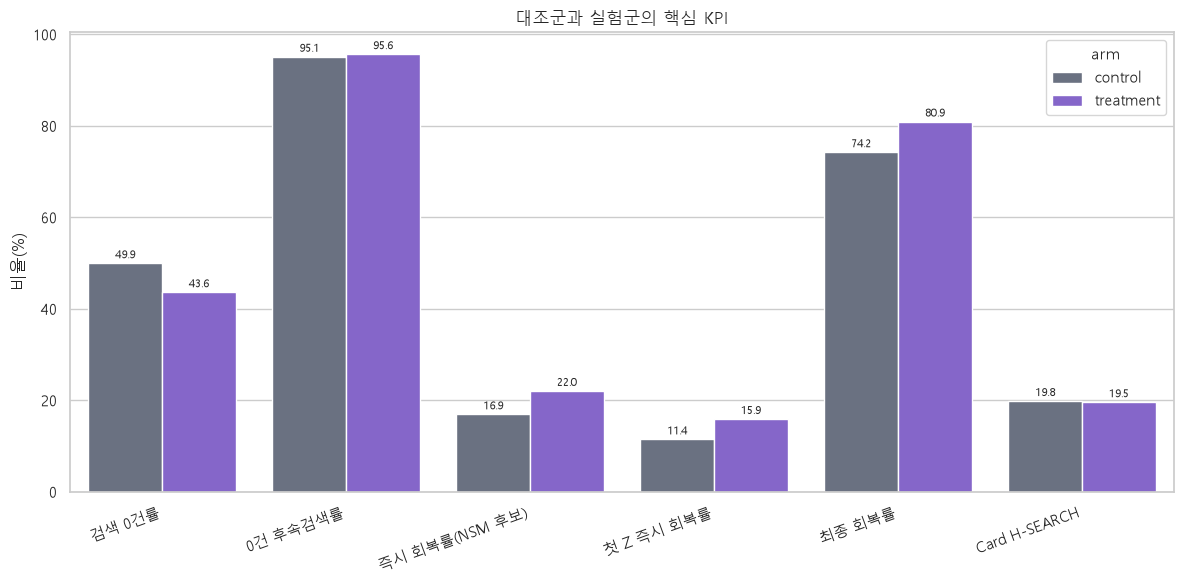

In [9]:
# 그림 1: KPI 수준
plotm=metrics.copy(); plotm['rate_pct']=plotm.rate*100
plt.figure(figsize=(12,6))
ax=sns.barplot(data=plotm,x='metric',y='rate_pct',hue='arm',palette=['#667085','#7F56D9'])
ax.set(xlabel='',ylabel='비율(%)',title='대조군과 실험군의 핵심 KPI')
plt.xticks(rotation=20,ha='right')
for cont in ax.containers: ax.bar_label(cont,fmt='%.1f',padding=2,fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'01_kpi_control_treatment.png',dpi=180); plt.show()


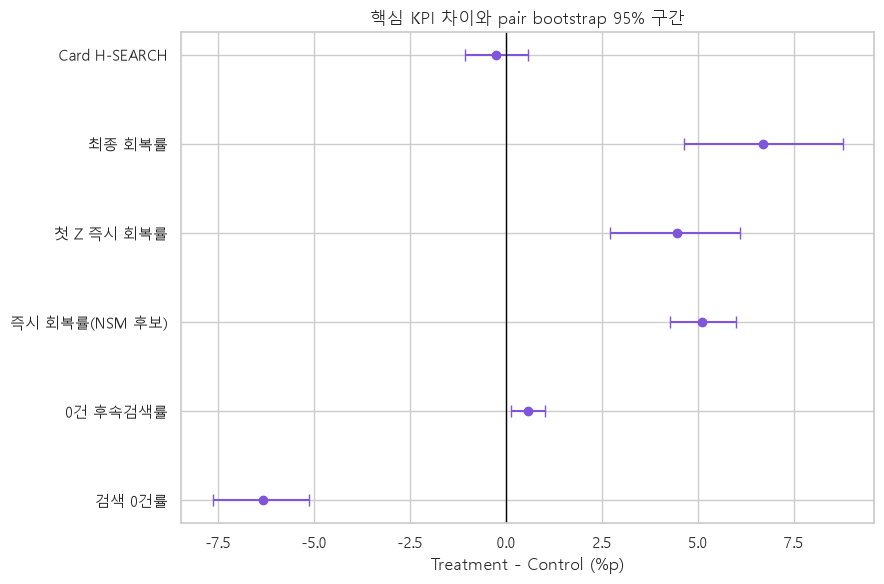

In [10]:
# 그림 2: 차이와 bootstrap 구간
order=['검색 0건률','0건 후속검색률','즉시 회복률(NSM 후보)','첫 Z 즉시 회복률','최종 회복률','Card H-SEARCH']
f=ci.set_index('metric').loc[order].reset_index()
plt.figure(figsize=(9,6)); y=np.arange(len(f))
plt.errorbar(f.difference_pp,y,xerr=[f.difference_pp-f.ci_low,f.ci_high-f.difference_pp],fmt='o',color='#7F56D9',capsize=4)
plt.axvline(0,color='black',lw=1); plt.yticks(y,f.metric); plt.xlabel('Treatment - Control (%p)'); plt.title('핵심 KPI 차이와 pair bootstrap 95% 구간')
plt.tight_layout(); plt.savefig(FIG/'02_kpi_uplift_ci.png',dpi=180); plt.show()


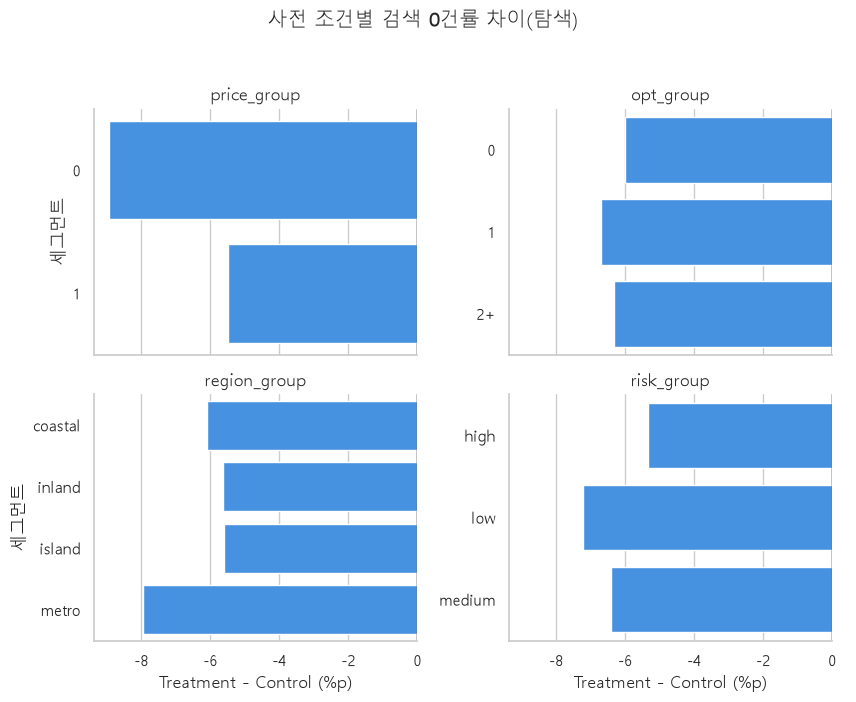

In [11]:
# 그림 3: 사전 조건별 검색 0건률 차이
g=sns.catplot(data=segments,x='difference_pp',y='segment',col='dimension',col_wrap=2,kind='bar',sharey=False,height=3.4,aspect=1.25,color='#2E90FA')
g.set_axis_labels('Treatment - Control (%p)','세그먼트'); g.set_titles('{col_name}')
for ax in g.axes.flat: ax.axvline(0,color='black',lw=1)
g.figure.suptitle('사전 조건별 검색 0건률 차이(탐색)',y=1.03)
plt.tight_layout(); plt.savefig(FIG/'03_segment_zero_rate.png',dpi=180,bbox_inches='tight'); plt.show()


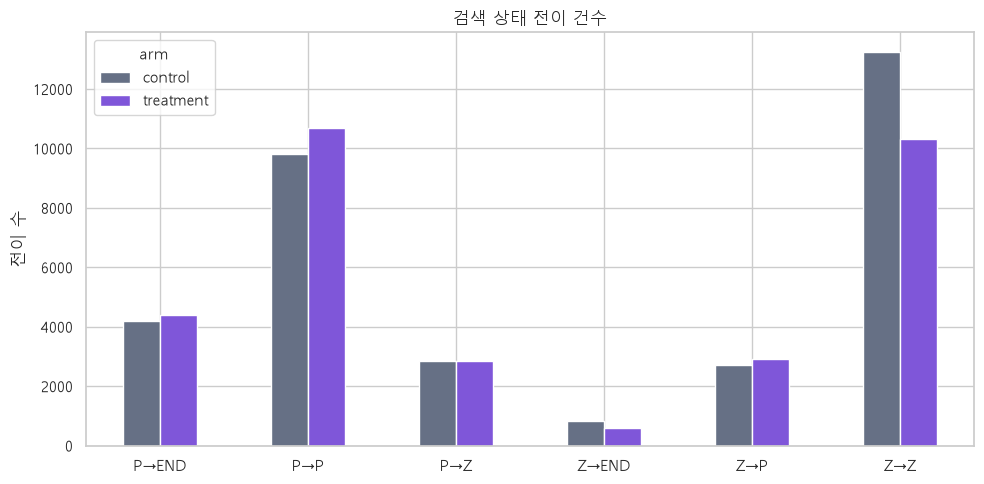

In [12]:
# 그림 4: 검색 상태 전이
trans=pd.read_sql_query("""SELECT u.sample_set_type arm,
CASE WHEN s1.total_result_count=0 THEN 'Z' ELSE 'P' END || '→' ||
CASE WHEN s2.search_id IS NULL THEN 'END' WHEN s2.total_result_count=0 THEN 'Z' ELSE 'P' END transition,
COUNT(*) n
FROM Search s1 JOIN SessionSynthetic ss ON ss.session_id=s1.session_id
JOIN UserSynthetic u ON u.user_id=ss.user_id
LEFT JOIN Search s2 ON s2.session_id=s1.session_id AND s2.search_sequence=s1.search_sequence+1
GROUP BY u.sample_set_type,transition""",con)
tp=trans.pivot(index='transition',columns='arm',values='n').fillna(0)
tp.plot(kind='bar',figsize=(10,5),color=['#667085','#7F56D9'])
plt.ylabel('전이 수'); plt.xlabel(''); plt.title('검색 상태 전이 건수'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(FIG/'04_transition_counts.png',dpi=180); plt.show()


## 8. 결과 저장과 계산 추적

원시 필드 → 파생 변수 → 분자·분모 → 비율을 CSV와 JSON으로 저장한다. 이 파일들로 Markdown 보고서의 모든 핵심 수치를 다시 확인할 수 있다.


In [13]:
metrics.to_csv(OUT/'metric_results.csv',index=False,encoding='utf-8-sig')
ci.to_csv(OUT/'metric_bootstrap_ci.csv',index=False,encoding='utf-8-sig')
segments.to_csv(OUT/'segment_results.csv',index=False,encoding='utf-8-sig')
h3.to_csv(OUT/'h3_recovery_detail.csv',encoding='utf-8-sig')
tp.to_csv(OUT/'transition_counts.csv',encoding='utf-8-sig')

summary={
 'db':str(DB),'quality':quality,
 'metrics':metrics.to_dict('records'),'ci':ci.to_dict('records'),
 'h3_recovery_detail':h3.reset_index().to_dict('records'),
 'hypothesis_status':{
   'H1':'합성 모형 안에서 지지; 실제 인과효과 아님',
   'H2':'검정 불가: intent_segment 없음',
   'H3':'탐색 가능; 회복자 사후집단이며 실제 인과효과 아님',
   'H4':'검정 불가: condition_keeper와 반복방지 전용 처치 없음',
   'H5':'검정 불가: location_flexible 없음, region_change와 +0.06 결합',
   'H6':'검정 불가: query_reframer와 검색어 제안 노출 로그 없음'
 }}
(OUT/'analysis_summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2,default=lambda x: float(x) if hasattr(x,'item') else str(x)),encoding='utf-8')
con.close()
print('saved:', OUT)


saved: c:\Users\ENCO\Documents\mission1\team_i\04_분석설계\팀프로젝트\2026\09\호텔검색_1만명NSMKPI가설분석_20260907_v01_현행본
